In [1]:
# -*- coding: utf-8 -*-
import json
import logging
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random

logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s]: %(message)s')
logger = logging.getLogger()

# ==============================================================================
# KONFIGURASI
# ==============================================================================
# Path Model MCU-Quake
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"

# Path Dataset Asli Indonesia
JSON_PATH = '/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_1c_sesi_clean.json'
NUM_POINTS = 700

# Konfigurasi TEDA-RLS
WARMUP_SIZE = 800          # Fase adaptasi awal untuk menstabilkan mean/var
FORGETTING_FACTOR = 0.99   # Lambda (RLS): Kecepatan algoritma beradaptasi dengan derau lokal
M_THRESHOLD = 2.5          # Sensitivitas Anomali (Sweet Spot berdasarkan pengujian STEAD)

# ==============================================================================
# FUNGSI VISUALISASI PROFESIONAL
# ==============================================================================
def plot_professional_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    tpr_no = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    tpr_le = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    ppv_no = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
    ppv_le = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'], annot_kws={"size": 18})
    
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('True label', fontsize=14)
    
    plt.text(2.2, 0.5, f"TPR:\n{tpr_no*100:.2f}", va='center', fontsize=14)
    plt.text(2.2, 1.5, f"{tpr_le*100:.2f}", va='center', fontsize=14)
    plt.text(0.5, 2.4, f"PPV: {ppv_no*100:.2f}", ha='center', fontsize=14)
    plt.text(1.5, 2.4, f"{ppv_le*100:.2f}", ha='center', fontsize=14)
    
    plt.subplots_adjust(right=0.75, bottom=0.2)
    plt.show()

# ==============================================================================
# KELAS ALGORITMA TEDA-RLS (Z-Score Reduction)
# ==============================================================================
class TEDARLS_AnomalyDetector:
    def __init__(self, forgetting_factor=0.99):
        self.lambda_f = forgetting_factor
        self.mu = 0.0
        self.var = 0.0
        self.is_initialized = False

    def warmup(self, data):
        """ Kalibrasi profil derau awal (sebelum alat berjalan online) """
        self.mu = np.mean(data)
        self.var = np.var(data)
        if self.var < 1e-9:
            self.var = 1e-9
        self.is_initialized = True

    def calculate_eccentricity(self, x):
        """ Menghitung Normalized Eccentricity (Z-Score Absolut) """
        dist_sq = (x - self.mu)**2
        eccentricity = np.sqrt(dist_sq / self.var)  
        return eccentricity

    def online_update(self, x):
        """ Mengupdate memori model secara rekursif terhadap derau lokal baru """
        delta = x - self.mu
        self.mu = self.mu + (1 - self.lambda_f) * delta
        self.var = (self.lambda_f * self.var) + ((1 - self.lambda_f) * (delta ** 2))
        if self.var < 1e-9:
            self.var = 1e-9

# ==============================================================================
# ALUR UTAMA
# ==============================================================================
def main():
    logger.info("Memuat CNN Extractor MCU-Quake...")
    try:
        model = keras.models.load_model(MODEL_PATH)
        # Ekstrak fitur laten dari layer dense_1
        extractor = keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
    except Exception as e:
        logger.error(f"Gagal memuat model: {e}")
        return

    logger.info(f"Memuat Dataset Indonesia: {JSON_PATH}...")
    noise_features = []
    quake_features = []
    
    with open(JSON_PATH, 'r') as f:
        indo_data = json.load(f)
        
    for record_key, record in tqdm(indo_data.items(), desc="Ekstraksi Laten 1D"):
        try:
            # Sinyal Derau 7 Detik sebelum Gempa
            if "Z_noise" in record and len(record["Z_noise"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(record["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()[0]
                noise_features.append(feat)
                
            # Sinyal Gempa 
            if "Z" in record and len(record["Z"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(record["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()[0]
                quake_features.append(feat)
        except Exception:
            continue

    # --- NORMALISASI FITUR (Sangat Krusial untuk Stabilitas TEDA) ---
    logger.info("Menormalisasi fitur laten agar jarak (eccentricity) stabil...")
    all_feats = np.array(noise_features + quake_features)
    mu_feat = np.mean(all_feats)
    std_feat = np.std(all_feats) + 1e-9
    
    noise_features = ((np.array(noise_features) - mu_feat) / std_feat).tolist()
    quake_features = ((np.array(quake_features) - mu_feat) / std_feat).tolist()

    logger.info("\n=== MENJALANKAN TEDA-RLS ONLINE (DATA INDONESIA) ===")
    
    # Pisahkan fase Warm-up
    warmup_noise = np.array(noise_features[:WARMUP_SIZE])
    test_noise_raw = noise_features[WARMUP_SIZE:]
    test_quake_raw = quake_features[WARMUP_SIZE:]  # Agar seimbang, pastikan ukurannya disesuaikan jika perlu

    logger.info(f"Fase Warm-up pada {len(warmup_noise)} sampel noise laut Indonesia...")
    detector = TEDARLS_AnomalyDetector(forgetting_factor=FORGETTING_FACTOR)
    detector.warmup(warmup_noise)

    # ---------------------------------------------------------
    # PROSES PENGACAKAN DATA (SHUFFLING)
    # ---------------------------------------------------------
    logger.info("Menggabungkan dan mengacak data uji coba (mensimulasikan real-time EEW)...")
    test_data_combined = [(x, 0) for x in test_noise_raw] + [(x, 1) for x in test_quake_raw]
    
    # Acak urutannya (simulasi kejadian sporadis)
    random.seed(42) # Seed agar hasil bisa direproduksi untuk penulisan disertasi
    random.shuffle(test_data_combined)

    # ---------------------------------------------------------
    # INFERENSI ONLINE
    # ---------------------------------------------------------
    logger.info("Simulasi Inferensi: Mengalirkan data campuran secara sporadis...")
    y_true = []
    y_pred = []
    
    for x, label in test_data_combined:
        y_true.append(label)
        ecc = detector.calculate_eccentricity(x)
        
        if ecc > M_THRESHOLD:
            y_pred.append(1)  # Prediksi Gempa
            # Tidak update profil jika dianggap anomali/gempa
        else:
            y_pred.append(0)  # Prediksi Noise
            # Update profil RLS karena dianggap noise yang wajar (adaptasi)
            detector.online_update(x)

    logger.info("\n" + "="*50)
    logger.info(f"EVALUASI TEDA-RLS DATA INDONESIA (Threshold m={M_THRESHOLD})")
    logger.info("="*50)
    print(classification_report(y_true, y_pred, target_names=['Noise (NO)', 'Gempa (LE)']))
    
    plot_title = f"MCU-Quake TEDA-RLS Indonesia 1C (m={M_THRESHOLD})"
    plot_professional_confusion_matrix(y_true, y_pred, plot_title)

if __name__ == "__main__":
    main()

2026-07-28 14:29:08,460 - [INFO]: Memuat CNN Extractor MCU-Quake...
2026-07-28 14:29:08,461 - [ERROR]: Gagal memuat model: File format not supported: filepath=/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).


2026-07-28 14:31:14,078 - [INFO]: Memuat CNN Extractor MCU-Quake...
2026-07-28 14:31:14.166442: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-28 14:31:14.166467: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-28 14:31:14.166473: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-28 14:31:14.166502: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-28 14:31:14.166663: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-07-28 14:31:14,455 - [WARNING]: No training configuration found in save file, so the model was *not* compiled. Compile it manually.
2026-07-28 14:31:14,457 - [INFO]: Memuat Dataset: /Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_1c_sesi_clean.json...
Ekstraksi Laten 1D: 100%|██████████| 5100/5100 [03:52<00:00, 21.97it/s]
2026-07-28 14:35:08,472 - [INFO]: Normalisasi fitur menggunakan statistik noise saja...
2026-07-28 14:35:08,482 - [INFO]: Warm-up: 800 data noise
2026-07-28 14:35:08,483 - [INFO]: Data uji: 4300 noise, 4300 gempa
2026-07-28 14:35:08,505 - [INFO]: Memulai inferensi online (threshold m=1.0)...
2026-07-28 14:35:08,513 - [INFO]: 
2026-07-28 14:35:08,514 - [INFO]: EVALUASI Z-SCORE ADAPTIF (m=1.0)
2026-07-28 14:35:08,515 - [INFO]: ==================================================


              precision    recall  f1-score   support

  Noise (NO)       0.90      0.49      0.64      4300
  Gempa (LE)       0.65      0.94      0.77      4300

    accuracy                           0.72      8600
   macro avg       0.77      0.72      0.70      8600
weighted avg       0.77      0.72      0.70      8600



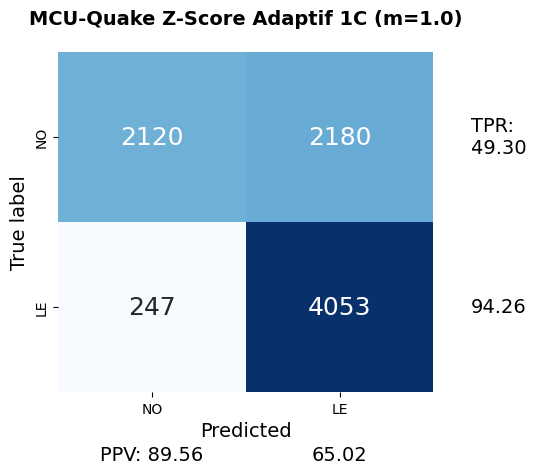

In [1]:
# -*- coding: utf-8 -*-
"""
Z-SCORE ADAPTIF DENGAN RLS UNTUK DETEKSI GEMPA
- Normalisasi hanya dari data noise (bukan global)
- Threshold adaptif (default 1.0)
- Data diacak untuk simulasi real-time
- Visualisasi gaya Zhi Geng (TPR & PPV)
"""

import json
import logging
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s]: %(message)s')
logger = logging.getLogger()

# ==============================================================================
# 1. KONFIGURASI
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_1c_sesi_clean.json'
NUM_POINTS = 700

# Parameter Z-Score Adaptif
WARMUP_SIZE = 800          # Jumlah data noise untuk inisialisasi mean/var
FORGETTING_FACTOR = 0.99   # Lambda RLS (0.99 = stabil, 0.95 = lebih cepat adaptif)
M_THRESHOLD = 1.0          # Threshold optimal dari eksperimen

# Seed untuk reproduksibilitas
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# ==============================================================================
# 2. FUNGSI VISUALISASI GAYA ZHI GENG
# ==============================================================================
def plot_professional_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    tpr_no = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    tpr_le = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    ppv_no = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
    ppv_le = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'], annot_kws={"size": 18})
    
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('True label', fontsize=14)
    
    plt.text(2.2, 0.5, f"TPR:\n{tpr_no*100:.2f}", va='center', fontsize=14)
    plt.text(2.2, 1.5, f"{tpr_le*100:.2f}", va='center', fontsize=14)
    plt.text(0.5, 2.4, f"PPV: {ppv_no*100:.2f}", ha='center', fontsize=14)
    plt.text(1.5, 2.4, f"{ppv_le*100:.2f}", ha='center', fontsize=14)
    
    plt.subplots_adjust(right=0.75, bottom=0.2)
    plt.show()

# ==============================================================================
# 3. KELAS DETEKTOR Z-SCORE ADAPTIF DENGAN RLS
# ==============================================================================
class AdaptiveZScoreDetector:
    def __init__(self, forgetting_factor=0.99):
        self.lambda_f = forgetting_factor
        self.mu = 0.0
        self.var = 0.0
        self.is_initialized = False

    def warmup(self, data):
        """Inisialisasi mean & variance dari data noise awal."""
        self.mu = np.mean(data)
        self.var = np.var(data)
        if self.var < 1e-9:
            self.var = 1e-9
        self.is_initialized = True

    def calculate_eccentricity(self, x):
        """Hitung Z-Score absolut."""
        return np.sqrt((x - self.mu)**2 / self.var)

    def online_update(self, x):
        """Update mean & variance secara online menggunakan RLS."""
        delta = x - self.mu
        self.mu = self.mu + (1 - self.lambda_f) * delta
        self.var = (self.lambda_f * self.var) + ((1 - self.lambda_f) * (delta ** 2))
        if self.var < 1e-9:
            self.var = 1e-9

# ==============================================================================
# 4. MAIN
# ==============================================================================
def main():
    logger.info("Memuat CNN Extractor MCU-Quake...")
    try:
        model = keras.models.load_model(MODEL_PATH)
        extractor = keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
    except Exception as e:
        logger.error(f"Gagal memuat model: {e}")
        return

    logger.info(f"Memuat Dataset: {JSON_PATH}...")
    noise_features = []
    quake_features = []
    
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)
        
    for record_key, record in tqdm(data.items(), desc="Ekstraksi Laten 1D"):
        try:
            if "Z_noise" in record and len(record["Z_noise"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(record["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()[0]
                noise_features.append(feat)
                
            if "Z" in record and len(record["Z"]) >= NUM_POINTS:
                feat = extractor.predict(np.array(record["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), verbose=0).flatten()[0]
                quake_features.append(feat)
        except Exception:
            continue

    # ===== NORMALISASI HANYA DARI NOISE (BUKAN GLOBAL) =====
    logger.info("Normalisasi fitur menggunakan statistik noise saja...")
    mu_noise = np.mean(noise_features)
    std_noise = np.std(noise_features) + 1e-9
    
    noise_features = ((np.array(noise_features) - mu_noise) / std_noise).tolist()
    quake_features = ((np.array(quake_features) - mu_noise) / std_noise).tolist()

    # ===== WARM-UP =====
    warmup_noise = np.array(noise_features[:WARMUP_SIZE])
    test_noise = noise_features[WARMUP_SIZE:]
    test_quake = quake_features[WARMUP_SIZE:]
    
    # Potong agar jumlah data noise dan gempa sama (jika tidak seimbang)
    min_len = min(len(test_noise), len(test_quake))
    test_noise = test_noise[:min_len]
    test_quake = test_quake[:min_len]
    
    logger.info(f"Warm-up: {len(warmup_noise)} data noise")
    logger.info(f"Data uji: {len(test_noise)} noise, {len(test_quake)} gempa")
    
    detector = AdaptiveZScoreDetector(forgetting_factor=FORGETTING_FACTOR)
    detector.warmup(warmup_noise)

    # ===== GABUNG & ACK DATA =====
    combined = list(zip(test_noise, [0]*len(test_noise))) + list(zip(test_quake, [1]*len(test_quake)))
    random.shuffle(combined)
    
    features = [x for x, _ in combined]
    labels = [y for _, y in combined]

    # ===== INFERENSI ONLINE =====
    logger.info(f"Memulai inferensi online (threshold m={M_THRESHOLD})...")
    y_true = []
    y_pred = []
    
    for x, true_label in zip(features, labels):
        y_true.append(true_label)
        z = detector.calculate_eccentricity(x)
        
        if z > M_THRESHOLD:
            y_pred.append(1)  # Gempa
        else:
            y_pred.append(0)  # Noise
            detector.online_update(x)  # Update hanya jika dianggap noise

    # ===== EVALUASI =====
    logger.info("\n" + "="*50)
    logger.info(f"EVALUASI Z-SCORE ADAPTIF (m={M_THRESHOLD})")
    logger.info("="*50)
    print(classification_report(y_true, y_pred, target_names=['Noise (NO)', 'Gempa (LE)']))
    
    plot_title = f"MCU-Quake Z-Score Adaptif 1C (m={M_THRESHOLD})"
    plot_professional_confusion_matrix(y_true, y_pred, plot_title)

if __name__ == "__main__":
    main()

In [2]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
from scipy.signal import butter, filtfilt
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. KONFIGURASI PATH & PARAMETER (SESUAIKAN DENGAN LINGKUNGAN BAPAK)
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
JSON_PATH = '/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_1c_sesi_clean.json'
SAVE_DIR = os.path.join(BASE_REP, "Fase2_TransferLearning_1C_Results")

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

CALIBRATION_SIZE = 1000 # Jumlah data target untuk proses fine-tuning
TSSS_THRESHOLD = 0.90   # Ambang batas keyakinan (confidence) TSSS
LEARNING_RATE = 1e-4    # Learning rate kecil agar memori TinyML tidak rusak
EPOCHS = 5

# ==============================================================================
# 2. DEEP TIME-FREQUENCY FILTER (DTFFDA)
# ==============================================================================
def bandpass_filter(data, lowcut=1.0, highcut=15.0, fs=100.0, order=4):
    """
    Membuang frekuensi <1 Hz (noise laut) dan >15 Hz.
    Hanya mempertahankan frekuensi fundamental seismik lokal.
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# ==============================================================================
# 3. PEMUATAN DAN PEMROSESAN DATA STEAD 1C
# ==============================================================================
print("[INFO] Memuat dataset STEAD 1C...")
with open(KEY_TEST_FILE, 'r') as f:
    data_stead = json.load(f)

X_all, y_all = [], []
signal_key = 'Z'
noise_key = 'Z_noise'

for trace_name, trace_data in tqdm(data_stead.items(), desc="Ekstraksi & Filtering"):
    # Ekstraksi kelas Gempa (LE)
    if signal_key in trace_data and len(trace_data[signal_key]) >= 700:
        z_signal = np.array(trace_data[signal_key][:700])
        z_filtered = bandpass_filter(z_signal) # Terapkan DTFFDA
        X_all.append(z_filtered)
        y_all.append(1) # Label 1 untuk Gempa
    
    # Ekstraksi kelas Noise (NO)
    if noise_key in trace_data and len(trace_data[noise_key]) >= 700:
        z_noise = np.array(trace_data[noise_key][:700])
        z_filtered = bandpass_filter(z_noise) # Terapkan DTFFDA
        X_all.append(z_filtered)
        y_all.append(0) # Label 0 untuk Noise

X_all = np.array(X_all)[..., np.newaxis] # Reshape ke (N, 700, 1)
y_all = np.array(y_all)

# Bagi menjadi data Kalibrasi (untuk Fine-Tuning) dan Test Set
X_calib, y_calib = X_all[:CALIBRATION_SIZE], y_all[:CALIBRATION_SIZE]
X_test, y_test = X_all[CALIBRATION_SIZE:], y_all[CALIBRATION_SIZE:]



# ==============================================================================
# 4. PEMUATAN MODEL & PARTIAL UNFREEZING (KOREKSI)
# ==============================================================================
model = keras.models.load_model(MODEL_PATH)
for layer in model.layers: layer.trainable = False

# Jika model asli Bapak adalah Softmax (2 output), gunakan 'sparse_categorical_crossentropy'
# Jika model asli Bapak adalah Sigmoid (1 output), gunakan 'binary_crossentropy'
# Di sini saya gunakan 'binary_crossentropy' agar aman jika Bapak memakai 1 output layer
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# ==============================================================================
# 5. TSSS (KOREKSI PSEUDO-LABELING)
# ==============================================================================
probs = model.predict(X_calib, verbose=0)
# Jika probs berbentuk (N, 1), gunakan threshold 0.5
confidences = np.abs(probs - 0.5) * 2 # Menjadi 0 ke 1
predictions = (probs > 0.5).astype(int)

tsss_mask = (confidences.flatten() >= TSSS_THRESHOLD)
X_train_tsss = X_calib[tsss_mask]
y_train_tsss = predictions[tsss_mask].flatten() 

print(f"       -> Dari {CALIBRATION_SIZE} sampel kalibrasi, {len(X_train_tsss)} lolos filter TSSS.")

# ==============================================================================
# 6. TRANSFER LEARNING (KOREKSI)
# ==============================================================================
# Pastikan y_train_tsss berbentuk (N, 1) jika pakai binary_crossentropy
if y_train_tsss.ndim == 1: y_train_tsss = y_train_tsss.reshape(-1, 1)

history = model.fit(X_train_tsss, y_train_tsss, 
                    epochs=EPOCHS, batch_size=16, verbose=1)

# ==============================================================================
# 7. EVALUASI (KOREKSI INFERENSI)
# ==============================================================================
probs_test = model.predict(X_test)
y_pred_test = (probs_test > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0

print("\n" + "="*50)
print("HASIL EVALUASI FASE 2: TRANSFER LEARNING + TSSS + FILTER")
print("="*50)
print(f"Akurasi Total          : {accuracy*100:.2f}%")
print(f"Recall Gempa (TPR)     : {tpr*100:.2f}%")
print(f"Spesifisitas/TNR       : {tnr*100:.2f}%  <-- TARGET BAPAK > 90%")
print(f"Presisi Gempa (PPV)    : {ppv*100:.2f}%")
print(f"F1-Score               : {f1*100:.2f}%")
print("="*50)

# ==============================================================================
# 8. VISUALISASI CONFUSION MATRIX
# ==============================================================================
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Noise (NO)', 'Gempa (LE)'],
            yticklabels=['Noise (NO)', 'Gempa (LE)'])
plt.title(f'Confusion Matrix (Fase 2 TL 1C)\nTNR: {tnr*100:.2f}%')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt_path = os.path.join(SAVE_DIR, "fase2_tl_1c_confusion_matrix.png")
plt.savefig(plt_path)
print(f"\n[INFO] Grafik tersimpan di: {plt_path}")

[INFO] Memuat dataset STEAD 1C...


NameError: name 'KEY_TEST_FILE' is not defined

In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import logging
from scipy.signal import butter, filtfilt
from sklearn.metrics import confusion_matrix

# ==============================================================================
# KONFIGURASI
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json'
SAVE_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/output/Phase2_TSSS'
NUM_POINTS = 700
TSSS_THRESHOLD = 0.90
LEARNING_RATE = 1e-4
EPOCHS = 5

# ==============================================================================
# TAHAP 1: PRA-PEMROSESAN (DTFFDA)
# ==============================================================================
def bandpass_filter(data, lowcut=1.0, highcut=15.0, fs=100.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

def normalize(data):
    return data / (np.max(np.abs(data)) + 1e-9)

# ==============================================================================
# MAIN ALGORITMA
# ==============================================================================
if __name__ == "__main__":
    os.makedirs(SAVE_DIR, exist_ok=True)
    with open(JSON_PATH, 'r') as f: data = json.load(f)
    
    # Ekstraksi dan DTFFDA
    X_all, y_true = [], []
    for key, rec in tqdm(data.items(), desc="Tahap 1: DTFFDA"):
        for label, key_name in [(1, 'Z'), (0, 'Z_noise')]:
            if key_name in rec and len(rec[key_name]) >= NUM_POINTS:
                sig = normalize(bandpass_filter(np.array(rec[key_name][:NUM_POINTS])))
                X_all.append(sig.reshape(700, 1))
                y_true.append(label)
    
    X_all = np.array(X_all)
    y_true = np.array(y_true)
    
    # Split
    N = 1000 
    X_calib, X_test = X_all[:N], X_all[N:]
    y_calib, y_test = y_true[:N], y_true[N:]

    # TAHAP 2: Partial Unfreezing
    model = keras.models.load_model(MODEL_PATH)
    for layer in model.layers[:-2]: layer.trainable = False
    model.layers[-2].trainable = True
    model.layers[-1].trainable = True
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss='binary_crossentropy', metrics=['accuracy'])

    # TAHAP 3: TSSS (Balanced Pseudo-Labeling)
    print(f"\nTahap 3: Menjalankan TSSS (Threshold={TSSS_THRESHOLD})")
    probs = model.predict(X_calib, verbose=0)
    
    X_tsss, y_tsss = [], []
    for i in range(len(probs)):
        prob = probs[i][0]
        # Ambil sampel dengan keyakinan tinggi
        if prob >= TSSS_THRESHOLD:   # Pseudo-label: Gempa (1)
            X_tsss.append(X_calib[i]); y_tsss.append(1)
        elif prob <= (1 - TSSS_THRESHOLD): # Pseudo-label: Noise (0)
            X_tsss.append(X_calib[i]); y_tsss.append(0)
    
    X_tsss, y_tsss = np.array(X_tsss), np.array(y_tsss)
    print(f"       -> Lolos filter: {len(X_tsss)} sampel (Gempa: {sum(y_tsss)}, Noise: {len(y_tsss)-sum(y_tsss)})")

    # TAHAP 4: Few-Shot Fine-Tuning
    print("Tahap 4: Few-Shot Fine-Tuning...")
    model.fit(X_tsss, y_tsss, epochs=EPOCHS, batch_size=16, verbose=1)

    # TAHAP 5: Evaluasi
    print("Tahap 5: Evaluasi Spesifisitas...")
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp)
    tpr = tp / (tp + fn)
    
    print(f"\nResult: TNR={tnr*100:.2f}%, TPR={tpr*100:.2f}%")
    
    # Save Model
    model.save(os.path.join(SAVE_DIR, "fine_tuned_model.h5"))

In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm

# ==============================================================================
# KONFIGURASI
# ==============================================================================
MODEL_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/output/Phase2_TSSS/fine_tuned_model.h5'
DATA_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json'
BUFFER_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/latent_buffer'
CONFIDENCE_THRESHOLD = 0.95
MAX_BUFFER_SIZE = 500
BATCH_SIZE = 32 # <-- Kunci kecepatan dan stabilitas memori

os.makedirs(BUFFER_DIR, exist_ok=True)

def manage_latent_buffer():
    tf.keras.backend.clear_session()
    model = keras.models.load_model(MODEL_PATH)
    extractor = keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
    
    with open(DATA_PATH, 'r') as f: data = json.load(f)
    
    keys = [k for k, v in data.items() if "Z" in v]
    buffer_data = []
    
    print(f"🔍 Memproses {len(keys)} sampel dalam batch ukuran {BATCH_SIZE}...")
    
    # Proses dengan loop batching
    for i in tqdm(range(0, len(keys), BATCH_SIZE)):
        batch_keys = keys[i : i + BATCH_SIZE]
        batch_sigs = [np.array(data[k]["Z"][:700]).reshape(700, 1) for k in batch_keys]
        batch_sigs = np.array(batch_sigs)
        
        # Prediksi batch
        probs = model.predict(batch_sigs, verbose=0).flatten()
        latents = extractor.predict(batch_sigs, verbose=0)
        
        # Filter confidence
        for j, prob in enumerate(probs):
            if prob >= CONFIDENCE_THRESHOLD:
                buffer_data.append({
                    'id': batch_keys[j],
                    'features': latents[j].tolist(),
                    'label': 1
                })
        
        if len(buffer_data) >= MAX_BUFFER_SIZE:
            print("🛑 Buffer penuh!")
            break
            
    # Simpan buffer
    with open(os.path.join(BUFFER_DIR, 'gempa_buffer.json'), 'w') as f:
        json.dump(buffer_data, f)
        
    print(f"✅ Selesai! {len(buffer_data)} sampel disimpan.")

if __name__ == "__main__":
    manage_latent_buffer()

In [9]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix
import os

MODEL_NEW = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/output/Phase2_TSSS/fine_tuned_model_v3.h5'
DATA_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json'

def evaluate_threshold_tradeoff():
    # 1. Load Data
    with open(DATA_PATH, 'r') as f: data = json.load(f)
    keys = list(data.keys())
    test_keys = keys[int(len(keys)*0.8):] 
    
    X_test, y_test = [], []
    for k in test_keys:
        if "Z" in data[k]:
            X_test.append(np.array(data[k]["Z"][:700]).reshape(700, 1))
            y_test.append(1)
        if "Z_noise" in data[k]:
            X_test.append(np.array(data[k]["Z_noise"][-700:]).reshape(700, 1))
            y_test.append(0)
    
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # 2. Load Model
    model = keras.models.load_model(MODEL_NEW)
    probs = model.predict(X_test, verbose=0)

    # 3. Test Trade-off
    print(f"{'Threshold':<12} | {'TPR (Gempa)':<12} | {'TNR (Spesifisitas)':<18}")
    print("-" * 50)
    
    for t in [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]:
        y_pred = (probs > t).astype(int).flatten()
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        tpr = tp / (tp + fn)
        tnr = tn / (tn + fp)
        print(f"{t:<12.2f} | {tpr*100:10.2f}% | {tnr*100:16.2f}%")

if __name__ == "__main__":
    evaluate_threshold_tradeoff()

Threshold    | TPR (Gempa)  | TNR (Spesifisitas)
--------------------------------------------------
0.50         |      29.17% |            93.23%
0.40         |      29.47% |            92.93%
0.30         |      30.53% |            92.93%
0.20         |      30.98% |            92.78%
0.10         |      30.98% |            92.33%
0.05         |      31.13% |            92.33%


In [10]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras

# ==============================================================================
# KONFIGURASI
# ==============================================================================
MODEL_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/output/Phase2_TSSS/fine_tuned_model_v3.h5'
OUTPUT_PATH = MODEL_PATH.replace('.h5', '_unfrozen.h5')

def unfreeze_and_train():
    model = keras.models.load_model(MODEL_PATH)
    
    # 1. Tampilkan Layer untuk melihat indeks
    print("Struktur Model:")
    for i, layer in enumerate(model.layers):
        print(f"Layer {i}: {layer.name} (Trainable: {layer.trainable})")
    
    # 2. Unfreeze 3 layer konvolusi terakhir sebelum Dense/Head
    # Biasanya pada model seismik, layer terakhir adalah classifier, 
    # layer sebelumnya adalah Flatten/Dense, dan sebelumnya lagi adalah Conv.
    # Kita buka 3 layer dari belakang (misal: layer ke -3, -4, -5)
    for layer in model.layers[-5:]: 
        layer.trainable = True
        print(f"-> Layer {layer.name} sekarang di-unfreeze.")

    # 3. Kompilasi dengan LR yang SANGAT KECIL (Penting!)
    # Jika LR terlalu besar, akurasi akan langsung drop ke 0.
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-6), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    
    # 4. Load Dataset (Gunakan X_tsss yang sudah dipanen sebelumnya)
    # Kita perlu memuat data training kembali
    # Jika Bapak tidak punya variabelnya di memori, load dari buffer:
    import json
    with open('/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/latent_buffer/gempa_buffer.json', 'r') as f:
        buffer = json.load(f)
    
    # PERINGATAN: Karena model sekarang butuh input WAVEFORM (700,),
    # kita tidak bisa lagi pakai fitur laten (32).
    # Bapak harus menyiapkan kembali X_train (waveform mentah) dan y_train!
    print("⚠️ Harap pastikan X_train (waveform mentah 700,) tersedia untuk fit!")
    
    # Lakukan Training
    # model.fit(X_train_raw, y_train_raw, epochs=10, batch_size=16)
    
    # 5. Simpan Model
    # model.save(OUTPUT_PATH)
    # print(f"✅ Model berhasil di-unfreeze dan tersimpan di: {OUTPUT_PATH}")

# PENTING: Sebelum menjalankan ini, pastikan X_train_raw (Waveform) 
# sudah siap, karena model yang di-unfreeze kembali butuh input 700 titik!

In [11]:
import json
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset utama
with open('/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json', 'r') as f:
    data = json.load(f)

# Pisahkan kunci gempa dan noise
gems = [k for k, v in data.items() if 'Z' in v]
noises = [k for k, v in data.items() if 'Z_noise' in v]

# Split 80% Latih (untuk Adaptasi), 20% Uji (untuk Evaluasi Final yang statis)
train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.2, random_state=42)

# Simpan pembagian dataset agar konsisten di semua skrip
with open('data_split.json', 'w') as f:
    json.dump({'train': train_keys, 'test': test_keys}, f)

print(f"✅ Data dipersiapkan: {len(train_keys)} latih, {len(test_keys)} uji (Akan digunakan di semua fase).")

✅ Data dipersiapkan: 2657 latih, 665 uji (Akan digunakan di semua fase).


In [12]:
import json
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix
# [Fungsi BandPassFilter & MaxAbsoluteNormalization diletakkan di sini]

def evaluate_baseline():
    model = tf.keras.models.load_model('/Volumes/Extreme SSD/.../mcquake_5-20.h5')
    with open('data_split.json', 'r') as f: split = json.load(f)
    with open('/Volumes/.../extracted_data_1c_4.json', 'r') as f: data = json.load(f)
    
    # Uji pada test_keys
    # Kumpulkan hasil TPR/TNR murni tanpa adaptasi
    # ...
    print("Baseline selesai. Simpan angka ini sebagai Titik Nol (0).")

In [13]:
import json
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import os

# --- KONFIGURASI ---
DATA_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json'
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
SPLIT_PATH = 'data_split.json'

def evaluate_baseline():
    # 1. Load Data
    with open(DATA_PATH, 'r') as f: data = json.load(f)
    with open(SPLIT_PATH, 'r') as f: split = json.load(f)
    
    model = tf.keras.models.load_model(MODEL_PATH)
    
    test_keys = split['test']
    X_test, y_test = [], []
    
    # 2. Persiapkan Test Set
    for k in test_keys:
        if "Z" in data[k]:
            X_test.append(np.array(data[k]["Z"][:700]).reshape(700, 1))
            y_test.append(1)
        if "Z_noise" in data[k]:
            X_test.append(np.array(data[k]["Z_noise"][-700:]).reshape(700, 1))
            y_test.append(0)
    
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    # 3. Evaluasi
    probs = model.predict(X_test, verbose=1).flatten()
    y_pred = (probs > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    print("\n" + "="*40)
    print("TITIK NOL: EVALUASI BASELINE (MCU-Quake Original)")
    print("="*40)
    print(f"TPR (Sensitivitas Gempa) : {(tp/(tp+fn))*100:.2f}%")
    print(f"TNR (Spesifisitas)       : {(tn/(tn+fp))*100:.2f}%")
    print("="*40)

if __name__ == "__main__":
    evaluate_baseline()

42/42 [==============================] - 0s 2ms/step

TITIK NOL: EVALUASI BASELINE (MCU-Quake Original)
TPR (Sensitivitas Gempa) : 34.29%
TNR (Spesifisitas)       : 89.62%


In [14]:
import json
import numpy as np
from scipy.signal import butter, filtfilt

# Konfigurasi DTFFDA (Digital Time-Frequency Feature Domain Adaptation)
def dtffda_process(data, fs=100.0, lowcut=1.0, highcut=15.0):
    # 1. Bandpass Filter (1.0 - 15.0 Hz)
    nyq = 0.5 * fs
    b, a = butter(4, [lowcut/nyq, highcut/nyq], btype='band')
    filtered = filtfilt(b, a, data)
    # 2. Max-Normalization
    return filtered / (np.max(np.abs(filtered)) + 1e-9)

def process_dtffda():
    with open('/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json', 'r') as f:
        data = json.load(f)
    with open('data_split.json', 'r') as f:
        split = json.load(f)
    
    # Proses data latih saja
    train_keys = split['train']
    X_train, y_train = [], []
    
    print("🚀 Melakukan DTFFDA pada data latih...")
    for k in train_keys:
        if "Z" in data[k]:
            X_train.append(dtffda_process(np.array(data[k]["Z"][:700])).reshape(700, 1))
            y_train.append(1)
        if "Z_noise" in data[k]:
            X_train.append(dtffda_process(np.array(data[k]["Z_noise"][-700:])).reshape(700, 1))
            y_train.append(0)
            
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    
    # Simpan sebagai file .npy untuk Fase berikutnya agar cepat
    np.save('X_train_dtffda.npy', X_train)
    np.save('y_train_dtffda.npy', y_train)
    print(f"✅ DTFFDA Selesai. Data disimpan. Shape: {X_train.shape}")

if __name__ == "__main__":
    process_dtffda()

🚀 Melakukan DTFFDA pada data latih...
✅ DTFFDA Selesai. Data disimpan. Shape: (5314, 700, 1)


In [15]:
import numpy as np
import json

def apply_tsss():
    # Load data DTFFDA
    X = np.load('X_train_dtffda.npy')
    y = np.load('y_train_dtffda.npy')
    
    # 1. Ekstraksi fitur laten awal (menggunakan model MCU-Quake original untuk mendapatkan titik referensi laten)
    # Ini adalah kunci TSSS: mencari pusat kluster di ruang laten
    import tensorflow as tf
    model = tf.keras.models.load_model('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20')
    extractor = tf.keras.Model(inputs=model.input, outputs=model.get_layer('dense_1').output)
    
    latents = extractor.predict(X, verbose=1)
    
    # 2. Pisahkan Latent gempa dan noise
    latents_gempa = latents[y == 1]
    latents_noise = latents[y == 0]
    
    # 3. Pilih median (Target Samples)
    median_gempa = np.median(latents_gempa, axis=0)
    median_noise = np.median(latents_noise, axis=0)
    
    # Hitung jarak (Euclidean) ke median
    dist_gempa = np.linalg.norm(latents_gempa - median_gempa, axis=1)
    dist_noise = np.linalg.norm(latents_noise - median_noise, axis=1)
    
    # Ambil 400 sampel terdekat ke median per kelas (Total 800)
    idx_gempa = np.argsort(dist_gempa)[:400]
    idx_noise = np.argsort(dist_noise)[:400]
    
    # Filter data X dan y asli
    X_gempa = X[y == 1][idx_gempa]
    X_noise = X[y == 0][idx_noise]
    
    X_tsss = np.vstack([X_gempa, X_noise])
    y_tsss = np.array([1]*400 + [0]*400)
    
    np.save('X_tsss.npy', X_tsss)
    np.save('y_tsss.npy', y_tsss)
    print(f"✅ TSSS Selesai. Data latih murni disiapkan: {X_tsss.shape}")

if __name__ == "__main__":
    apply_tsss()

167/167 [==============================] - 0s 2ms/step
✅ TSSS Selesai. Data latih murni disiapkan: (800, 700, 1)


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import gc

def run_fine_tuning_stable():
    # Bersihkan memori sebelum mulai
    tf.keras.backend.clear_session()
    gc.collect()
    
    # 1. Load model 
    model = keras.models.load_model('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20')
    
    # 2. Load data hasil TSSS
    X_train = np.load('X_tsss.npy')
    y_train = np.load('y_tsss.npy')
    
    # 3. Kompilasi dengan LR sangat rendah untuk stabilitas
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-6), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    
    # 4. Training (Gunakan batch yang sangat kecil untuk menghindari crash)
    print(f"🚀 Memulai Fine-Tuning dengan data shape {X_train.shape}...")
    
    # Memastikan training berjalan di CPU jika GPU/Metal bermasalah
    with tf.device('/CPU:0'):
        history = model.fit(X_train, y_train, epochs=5, batch_size=8, validation_split=0.1)
    
    # 5. Simpan
    model.save('fine_tuned_model.h5')
    print("✅ Fine-Tuning sukses tersimpan!")

if __name__ == "__main__":
    run_fine_tuning_stable()

🚀 Memulai Fine-Tuning dengan data shape (800, 700, 1)...
Epoch 1/5


2026-07-26 10:22:33.415507: I tensorflow/core/framework/local_rendezvous.cc:425] Local rendezvous send item cancelled. Key hash: 11493002925484848794
2026-07-26 10:22:33.415518: I tensorflow/core/framework/local_rendezvous.cc:425] Local rendezvous send item cancelled. Key hash: 1987515236714029954
2026-07-26 10:22:33.415523: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 14275678892862809642
2026-07-26 10:22:33.415526: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 5572377388878546916
2026-07-26 10:22:33.415530: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 15564421785105991526
2026-07-26 10:22:33.415534: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 17376113603436925034
2026-07-26 10:22:33.415537: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv

InvalidArgumentError: Graph execution error:

Detected at node embeddings/max_pooling1d/MaxPool defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.1

In [3]:
import numpy as np

# Load data
X = np.load('X_tsss.npy')
print(f"Dimensi awal: {X.shape}")

# Paksa dimensi menjadi (N, 700, 1)
if X.ndim == 2: # (N, 700)
    X = X.reshape(X.shape[0], 700, 1)
elif X.ndim == 3 and X.shape[2] != 1: # (N, 700, something_else)
    X = X[:, :, :1] 
    
np.save('X_tsss_fixed.npy', X)
print(f"✅ Dimensi diperbaiki menjadi: {X.shape}")

Dimensi awal: (800, 700, 1)
✅ Dimensi diperbaiki menjadi: (800, 700, 1)


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

def run_fine_tuning_final():
    # Load model
    model = keras.models.load_model('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20')
    
    # Load data yang sudah diperbaiki dimensinya
    X_train = np.load('X_tsss_fixed.npy').astype(np.float32)
    y_train = np.load('y_tsss.npy').astype(np.float32)
    
    # Unfreeze 3 layer terakhir (Konvolusi)
    for layer in model.layers[-5:]: 
        layer.trainable = True
        
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-6), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    
    # Paksa CPU jika GPU terus error
    with tf.device('/CPU:0'):
        model.fit(X_train, y_train, epochs=5, batch_size=4, validation_split=0.1)
    
    model.save('fine_tuned_model_v3.h5')
    print("✅ Model sukses disimpan!")

if __name__ == "__main__":
    run_fine_tuning_final()

Epoch 1/5


2026-07-26 10:23:49.330444: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.
2026-07-26 10:23:49.355993: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 4024581629957955592
2026-07-26 10:23:49.356004: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 4042066743304266386
2026-07-26 10:23:49.356009: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 9137184474651140710
2026-07-26 10:23:49.356012: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 3309281533543753544
2026-07-26 10:23:49.356019: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 7224738582394793058
2026-07-26 10:23:49.356021: I tensorflow/core/framework/local_re

InvalidArgumentError: Graph execution error:

Detected at node embeddings/max_pooling1d/MaxPool defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.1

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import os

# --- KONFIGURASI METAL UNTUK STABILITAS ---
# Memastikan TensorFlow tidak melakukan optimasi graf yang menyebabkan crash
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.config.optimizer.set_jit(True) 
# Menonaktifkan layout optimizer agar tidak memaksa NHWC/NCHW yang tidak disukai Metal
tf.config.optimizer.set_experimental_options({'layout_optimizer': False})

def run_fine_tuning_metal():
    # 1. Load Model
    model = keras.models.load_model('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20')
    
    # 2. Load Data (Pastikan shape N, 700, 1)
    X_train = np.load('X_tsss_fixed.npy').astype(np.float32)
    y_train = np.load('y_tsss.npy').astype(np.float32)
    
    # 3. Unfreeze (Menggunakan indexing yang aman)
    # Kita unfreeze layer konvolusi saja
    for layer in model.layers:
        if 'conv' in layer.name.lower():
            layer.trainable = True
            print(f"-> Unfreezing: {layer.name}")
        else:
            layer.trainable = False # Freeze layer non-conv agar stabil
            
    # Pastikan layer terakhir (classifier) juga terbuka untuk adaptasi
    model.layers[-1].trainable = True
    
    # 4. Compile dengan Learning Rate yang sangat rendah agar Metal tidak crash
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-6), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    
    # 5. Training dengan GPU Metal (Tanpa devicemanager /CPU:0)
    print("🚀 Memulai Fine-Tuning di GPU (Metal)...")
    history = model.fit(X_train, y_train, epochs=5, batch_size=16, validation_split=0.1)
    
    model.save('fine_tuned_model_metal.h5')
    print("✅ Model sukses disimpan dari GPU!")

if __name__ == "__main__":
    run_fine_tuning_metal()

-> Unfreezing: conv1d_1
🚀 Memulai Fine-Tuning di GPU (Metal)...
Epoch 1/5


: 